In [11]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel

In [3]:
# Step 1: Load model + tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Step 2: Input text
sentence = "The movie was not good at all."

In [5]:
# Step 3: Tokenize input
inputs = tokenizer(sentence, return_tensors='pt')

In [6]:
# Step 4: Run model
outputs = model(**inputs)

In [7]:
# Step 5: Get attention weights
attentions = outputs.attentions  # tuple of layers

In [8]:
# Step 6: Select one layer and one head
layer = 0
head = 0
attention_matrix = attentions[layer][0][head].detach().numpy()

In [9]:
# Step 7: Get tokens
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

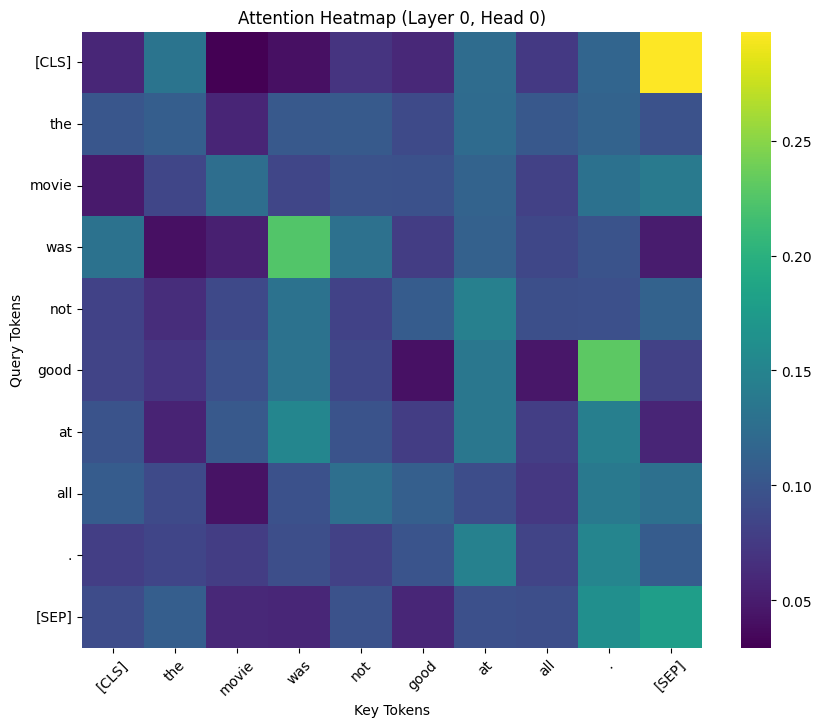

In [10]:
# Step 8: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")

plt.title(f"Attention Heatmap (Layer {layer}, Head {head})")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()